In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)

RESULTS = {}

## Case Study 1 — Iris Species Classification (Multiclass)


In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

In [3]:
baseline = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42)
baseline.fit(X_train_s, y_train)
y_pred_base = baseline.predict(X_test_s)

RESULTS["CS1_baseline_sklearn_10"] = dict(
    accuracy=accuracy_score(y_test, y_pred_base),
    precision=precision_score(y_test, y_pred_base, average="macro"),
    recall=recall_score(y_test, y_pred_base, average="macro"),
)
RESULTS["CS1_baseline_sklearn_10"]

{'accuracy': 0.9666666666666667,
 'precision': 0.9696969696969697,
 'recall': 0.9666666666666667}

In [4]:
best_sklearn = MLPClassifier(
    hidden_layer_sizes=(20, 10), activation="relu", solver="adam",
    alpha=1e-3, learning_rate_init=0.01, max_iter=3000, random_state=42,
)
best_sklearn.fit(X_train_s, y_train)
y_pred_best = best_sklearn.predict(X_test_s)

RESULTS["CS1_tuned_sklearn_20_10"] = dict(
    accuracy=accuracy_score(y_test, y_pred_best),
    precision=precision_score(y_test, y_pred_best, average="macro"),
    recall=recall_score(y_test, y_pred_best, average="macro"),
)
RESULTS["CS1_tuned_sklearn_20_10"]

{'accuracy': 0.9666666666666667,
 'precision': 0.9696969696969697,
 'recall': 0.9666666666666667}

In [5]:
# --- Keras MLP ---
keras_model = keras.Sequential([
    keras.layers.Input(shape=(4,)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax"),
])
keras_model.compile(optimizer=keras.optimizers.Adam(0.005),loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True, monitor="val_accuracy")
keras_model.fit(X_train_s, y_train, validation_split=0.15, epochs=300,batch_size=8, callbacks=[es], verbose=0)

y_pred_keras = np.argmax(keras_model.predict(X_test_s, verbose=0), axis=1)
RESULTS["CS1_keras_64_32"] = dict(
    accuracy=accuracy_score(y_test, y_pred_keras),
    precision=precision_score(y_test, y_pred_keras, average="macro"),
    recall=recall_score(y_test, y_pred_keras, average="macro"),
)
RESULTS["CS1_keras_64_32"]

{'accuracy': 0.9333333333333333,
 'precision': 0.9333333333333332,
 'recall': 0.9333333333333332}

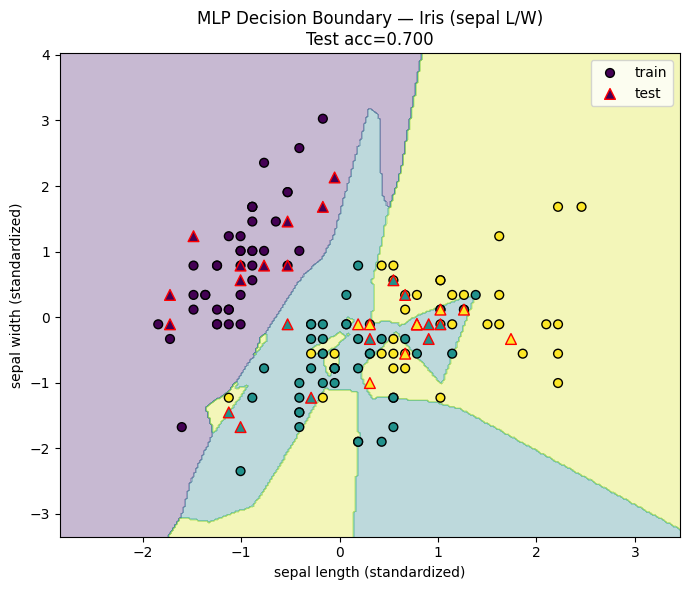

In [6]:
X2 = X[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split( X2, y, test_size=0.2, random_state=42, stratify=y)
scaler2 = StandardScaler().fit(X2_train)
X2_train_s, X2_test_s = scaler2.transform(X2_train), scaler2.transform(X2_test)

clf2 = MLPClassifier(hidden_layer_sizes=(20, 10), max_iter=5000,learning_rate_init=0.01, random_state=42, n_iter_no_change=200)
clf2.fit(X2_train_s, y2_train)
acc2 = accuracy_score(y2_test, clf2.predict(X2_test_s))
RESULTS["CS1_2feature_boundary_model_acc"] = dict(accuracy=acc2)

x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.viridis)
plt.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train,
            cmap=plt.cm.viridis, edgecolor="k", s=40, label="train")
plt.scatter(X2_test_s[:, 0], X2_test_s[:, 1], c=y2_test, cmap=plt.cm.viridis,
            edgecolor="red", marker="^", s=60, label="test")
plt.xlabel("sepal length (standardized)")
plt.ylabel("sepal width (standardized)")
plt.title(f"MLP Decision Boundary — Iris (sepal L/W)\nTest acc={acc2:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig("cs1_decision_boundary.png", dpi=130)
plt.show()


## Case Study 2 — Diabetes Progression Prediction (Regression)


In [7]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = load_diabetes()
Xd, yd = data.data, data.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)
xd_scaler = StandardScaler().fit(Xd_train)
Xd_train_s, Xd_test_s = xd_scaler.transform(Xd_train), xd_scaler.transform(Xd_test)

yd_scaler = StandardScaler().fit(yd_train.reshape(-1, 1))
yd_train_s = yd_scaler.transform(yd_train.reshape(-1, 1)).ravel()

In [8]:
lin = LinearRegression().fit(Xd_train_s, yd_train)
pred_lin = lin.predict(Xd_test_s)
RESULTS["CS2_linear_regression"] = dict( mse=mean_squared_error(yd_test, pred_lin), r2=r2_score(yd_test, pred_lin))

ridge = Ridge(alpha=1.0).fit(Xd_train_s, yd_train)
pred_ridge = ridge.predict(Xd_test_s)
RESULTS["CS2_ridge_regression"] = dict(mse=mean_squared_error(yd_test, pred_ridge), r2=r2_score(yd_test, pred_ridge))
RESULTS["CS2_linear_regression"], RESULTS["CS2_ridge_regression"]

({'mse': 2900.1936284934823, 'r2': 0.45260276297191926},
 {'mse': 2892.014565750171, 'r2': 0.45414652070698247})

In [9]:
mlp_base = MLPRegressor(hidden_layer_sizes=(20, 10), max_iter=5000, random_state=42)
mlp_base.fit(Xd_train_s, yd_train)
pred_base = mlp_base.predict(Xd_test_s)
RESULTS["CS2_mlp_baseline_20_10"] = dict(mse=mean_squared_error(yd_test, pred_base), r2=r2_score(yd_test, pred_base))
RESULTS["CS2_mlp_baseline_20_10"]

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


{'mse': 3217.2659505631254, 'r2': 0.3927569267029942}

In [10]:
best_cfg, best_r2, best_pred = None, -np.inf, None
for hidden in [(20, 10), (32, 16), (64, 32), (16,), (100, 50)]:
    for alpha in [1e-3, 1e-2, 1e-1]:
        m = MLPRegressor(hidden_layer_sizes=hidden, alpha=alpha, activation="relu",
                          solver="adam", learning_rate_init=0.005, max_iter=5000,
                          early_stopping=True, n_iter_no_change=40, random_state=42)
        m.fit(Xd_train_s, yd_train)
        p = m.predict(Xd_test_s)
        r2 = r2_score(yd_test, p)
        if r2 > best_r2:
            best_r2, best_cfg, best_pred = r2, (hidden, alpha), p

RESULTS["CS2_mlp_tuned_best_config"] = dict(
    hidden_layers=str(best_cfg[0]), alpha=best_cfg[1],
    mse=mean_squared_error(yd_test, best_pred), r2=best_r2
)
RESULTS["CS2_mlp_tuned_best_config"]

{'hidden_layers': '(16,)',
 'alpha': 0.1,
 'mse': 2728.540524890734,
 'r2': 0.48500143929348905}

In [11]:
keras_reg = keras.Sequential([
    keras.layers.Input(shape=(Xd_train_s.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1),
])
keras_reg.compile(optimizer=keras.optimizers.Adam(0.005), loss="mse")
es = keras.callbacks.EarlyStopping(patience=40, restore_best_weights=True, monitor="val_loss")
keras_reg.fit(Xd_train_s, yd_train_s, validation_split=0.15, epochs=500,batch_size=16, callbacks=[es], verbose=0)

pred_keras_s = keras_reg.predict(Xd_test_s, verbose=0).ravel()
pred_keras = yd_scaler.inverse_transform(pred_keras_s.reshape(-1, 1)).ravel()
RESULTS["CS2_keras_mlp"] = dict(mse=mean_squared_error(yd_test, pred_keras), r2=r2_score(yd_test, pred_keras))
RESULTS["CS2_keras_mlp"]

{'mse': 2686.6525014873614, 'r2': 0.4929075970238902}


## Case Study 3 — Wine Quality (Type) Classification — Imbalanced Multiclass



In [12]:
from sklearn.datasets import load_wine
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, f1_score)
from sklearn.inspection import permutation_importance

wine = load_wine()
Xw, yw = wine.data, wine.target
wine_feature_names = wine.feature_names

print("Class distribution:", np.bincount(yw))

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    Xw, yw, test_size=0.2, random_state=42, stratify=yw
)
w_scaler = StandardScaler().fit(Xw_train)
Xw_train_s, Xw_test_s = w_scaler.transform(Xw_train), w_scaler.transform(Xw_test)

Class distribution: [59 71 48]


In [13]:
wine_clf = MLPClassifier(
    hidden_layer_sizes=(50, 25), activation="relu", solver="adam",
    alpha=1e-3, learning_rate_init=0.005, max_iter=3000,
    early_stopping=True, n_iter_no_change=30, validation_fraction=0.15,
    random_state=42,
)
wine_clf.fit(Xw_train_s, yw_train)
yw_pred = wine_clf.predict(Xw_test_s)

RESULTS["CS3_accuracy"] = accuracy_score(yw_test, yw_pred)
RESULTS["CS3_f1_macro"] = f1_score(yw_test, yw_pred, average="macro")
print(classification_report(yw_test, yw_pred, target_names=wine.target_names))

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



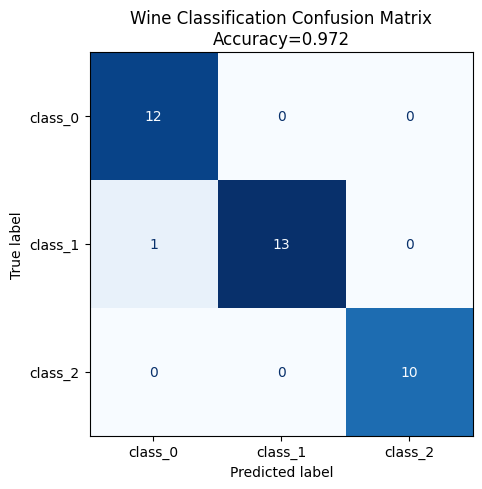

In [14]:
cm = confusion_matrix(yw_test, yw_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Wine Classification Confusion Matrix\nAccuracy={RESULTS['CS3_accuracy']:.3f}")
plt.tight_layout()
plt.savefig("cs3_confusion_matrix.png", dpi=130)
plt.show()

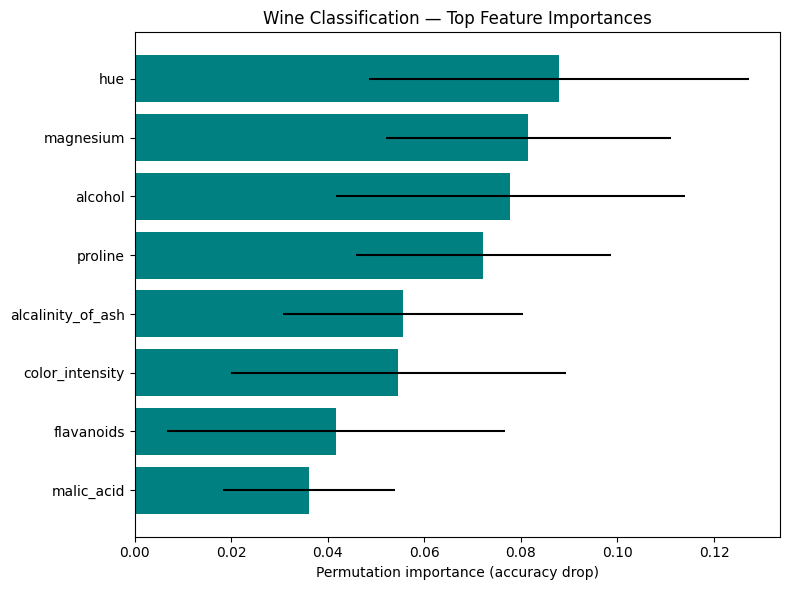

[{'feature': 'hue',
  'importance_mean': np.float64(0.08796296296296297),
  'importance_std': np.float64(0.03933823293749627)},
 {'feature': 'magnesium',
  'importance_mean': np.float64(0.0814814814814815),
  'importance_std': np.float64(0.02951366194538743)},
 {'feature': 'alcohol',
  'importance_mean': np.float64(0.07777777777777779),
  'importance_std': np.float64(0.03614670610359839)},
 {'feature': 'proline',
  'importance_mean': np.float64(0.07222222222222226),
  'importance_std': np.float64(0.026449734920529062)},
 {'feature': 'alcalinity_of_ash',
  'importance_mean': np.float64(0.05555555555555558),
  'importance_std': np.float64(0.02484519974999766)},
 {'feature': 'color_intensity',
  'importance_mean': np.float64(0.05462962962962965),
  'importance_std': np.float64(0.03475615625763604)}]

In [15]:
perm = permutation_importance(wine_clf, Xw_test_s, yw_test, n_repeats=30,
                               random_state=42, n_jobs=-1)
order = perm.importances_mean.argsort()[::-1]
RESULTS["CS3_permutation_importance_top"] = [
    {"feature": wine_feature_names[i],
     "importance_mean": perm.importances_mean[i],
     "importance_std": perm.importances_std[i]}
    for i in order[:6]
]

plt.figure(figsize=(8, 6))
plt.barh([wine_feature_names[i] for i in order[:8][::-1]],
         perm.importances_mean[order[:8][::-1]],
         xerr=perm.importances_std[order[:8][::-1]], color="teal")
plt.xlabel("Permutation importance (accuracy drop)")
plt.title("Wine Classification — Top Feature Importances")
plt.tight_layout()
plt.savefig("cs3_permutation_importance.png", dpi=130)
plt.show()

RESULTS["CS3_permutation_importance_top"]


## Case Study 4 — Synthetic Non-Linear Boundary Prediction



In [16]:
from sklearn.datasets import make_moons, make_circles

def plot_boundary(ax, clf, Xb, yb, title):
    x_min, x_max = Xb[:, 0].min() - 0.5, Xb[:, 0].max() + 0.5
    y_min, y_max = Xb[:, 1].min() - 0.5, Xb[:, 1].max() + 0.5
    xxb, yyb = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Zb = clf.predict(np.c_[xxb.ravel(), yyb.ravel()]).reshape(xxb.shape)
    ax.contourf(xxb, yyb, Zb, alpha=0.35, cmap=plt.cm.coolwarm)
    ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap=plt.cm.coolwarm, edgecolor="k", s=15)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

datasets = {
    "moons": make_moons(n_samples=1000, noise=0.2, random_state=42),
    "circles": make_circles(n_samples=1000, noise=0.15, factor=0.4, random_state=42),
}

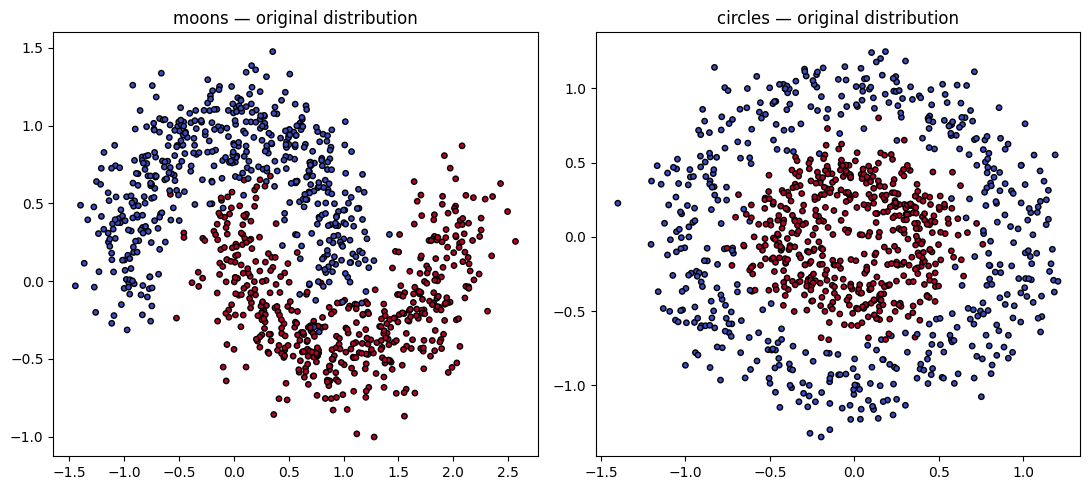

In [17]:
# --- Original distributions ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (name, (Xs, ys)) in zip(axes, datasets.items()):
    ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap=plt.cm.coolwarm, edgecolor="k", s=15)
    ax.set_title(f"{name} — original distribution")
plt.tight_layout()
plt.savefig("cs4_distributions.png", dpi=130)
plt.show()

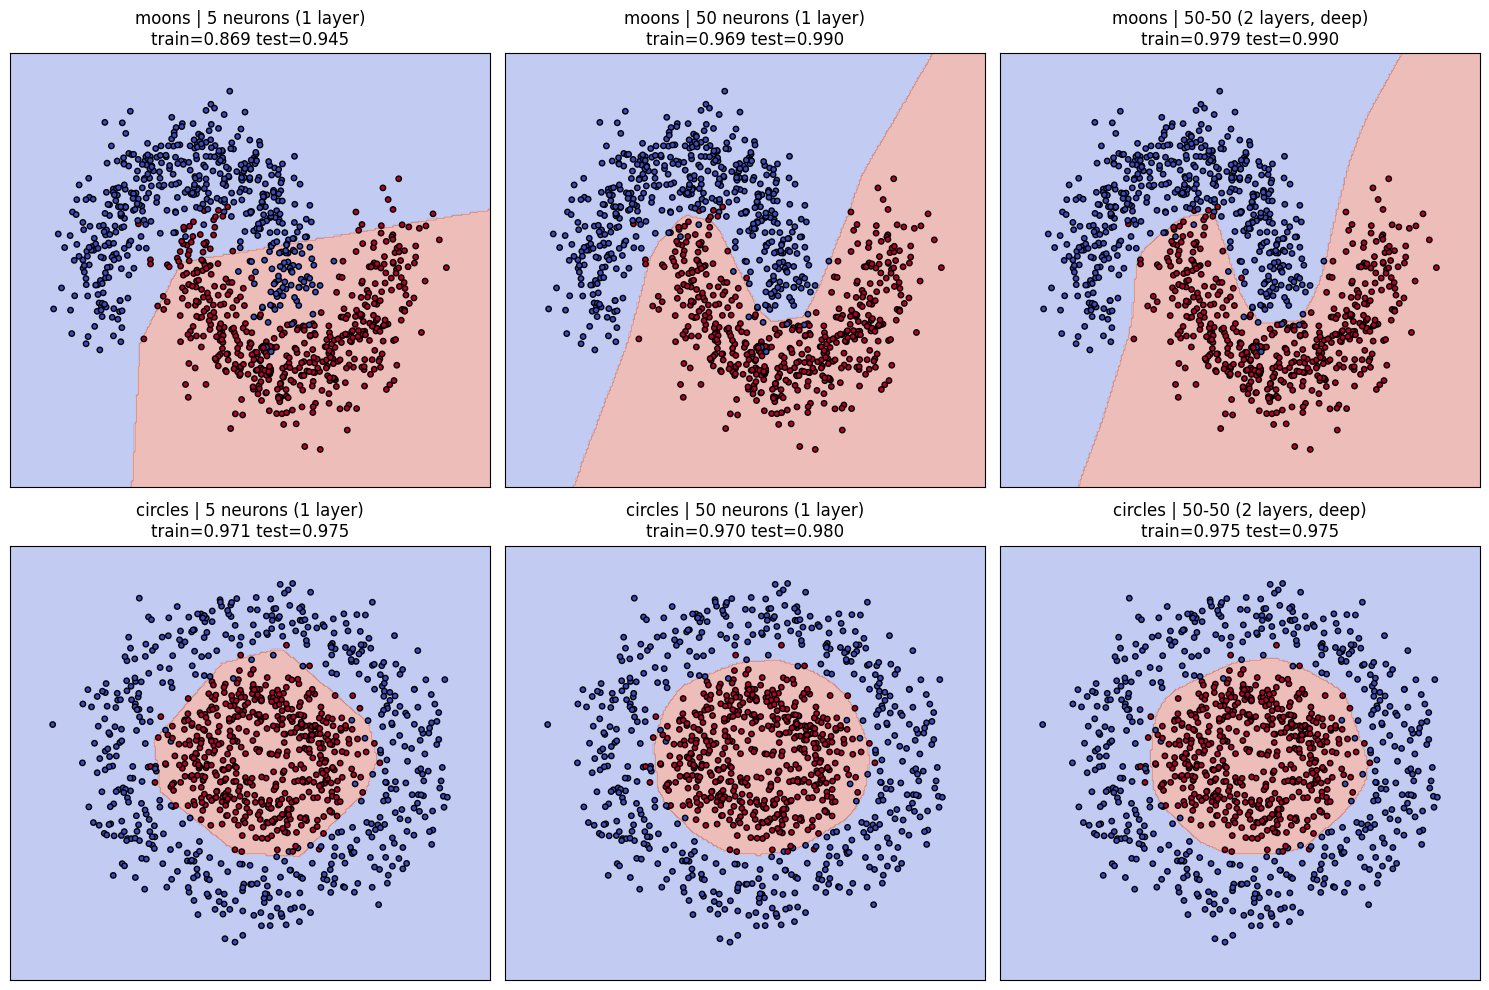

In [18]:
archs = {"5 neurons (1 layer)": (5,), "50 neurons (1 layer)": (50,),
         "50-50 (2 layers, deep)": (50, 50)}

fig, axes = plt.subplots(len(datasets), len(archs), figsize=(5 * len(archs), 5 * len(datasets)))

for row, (dname, (Xs, ys)) in enumerate(datasets.items()):
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        Xs, ys, test_size=0.2, random_state=42, stratify=ys
    )
    s_scaler = StandardScaler().fit(Xs_train)
    Xs_train_s, Xs_test_s = s_scaler.transform(Xs_train), s_scaler.transform(Xs_test)
    Xs_all_s = s_scaler.transform(Xs)

    for col, (aname, hidden) in enumerate(archs.items()):
        clf = MLPClassifier(hidden_layer_sizes=hidden, activation="relu", max_iter=3000,
                             random_state=42, alpha=1e-4)
        clf.fit(Xs_train_s, ys_train)
        train_acc = accuracy_score(ys_train, clf.predict(Xs_train_s))
        test_acc = accuracy_score(ys_test, clf.predict(Xs_test_s))
        RESULTS[f"CS4_{dname}_{aname}"] = dict(
            train_accuracy=train_acc, test_accuracy=test_acc, gap=train_acc - test_acc
        )
        ax = axes[row, col]
        plot_boundary(ax, clf, Xs_all_s, ys,
                      f"{dname} | {aname}\ntrain={train_acc:.3f} test={test_acc:.3f}")

plt.tight_layout()
plt.savefig("cs4_boundaries.png", dpi=130)
plt.show()


## Case Study 5 — Customer Churn Prediction (Binary, real-world tabular)



In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve

url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
       "master/data/Telco-Customer-Churn.csv")
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

target = "Churn"
yc = LabelEncoder().fit_transform(df[target])
Xc = df.drop(columns=[target])

cat_cols = Xc.select_dtypes(include="object").columns.tolist()
Xc_encoded = pd.get_dummies(Xc, columns=cat_cols, drop_first=True)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc_encoded, yc, test_size=0.2, random_state=42, stratify=yc
)
c_scaler = StandardScaler().fit(Xc_train)
Xc_train_s = c_scaler.transform(Xc_train)
Xc_test_s = c_scaler.transform(Xc_test)

RESULTS["CS5_class_balance"] = dict(churn_rate=float(yc.mean()), n_samples=len(yc))
RESULTS["CS5_class_balance"]

{'churn_rate': 0.2653698707936959, 'n_samples': 7043}

In [21]:
base = MLPClassifier(hidden_layer_sizes=(32,), solver="adam", max_iter=1000, random_state=42)
base.fit(Xc_train_s, yc_train)
proba_base = base.predict_proba(Xc_test_s)[:, 1]

RESULTS["CS5_baseline_mlp"] = dict(
    accuracy=accuracy_score(yc_test, base.predict(Xc_test_s)),
    roc_auc=roc_auc_score(yc_test, proba_base),
)
RESULTS["CS5_baseline_mlp"]

{'accuracy': 0.7771469127040455, 'roc_auc': np.float64(0.8207910305097005)}

In [22]:
param_grid = {
    "hidden_layer_sizes": [(32,), (64, 32), (32, 16)],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [0.001, 0.01],
}
gs = GridSearchCV(
    MLPClassifier(solver="adam", max_iter=500, early_stopping=True,
                  n_iter_no_change=15, random_state=42),
    param_grid, scoring="roc_auc", cv=3, n_jobs=-1,
)
gs.fit(Xc_train_s, yc_train)
best_model = gs.best_estimator_
proba_best = best_model.predict_proba(Xc_test_s)[:, 1]

RESULTS["CS5_grid_search_best_params"] = gs.best_params_
RESULTS["CS5_tuned_mlp"] = dict(
    accuracy=accuracy_score(yc_test, best_model.predict(Xc_test_s)),
    roc_auc=roc_auc_score(yc_test, proba_best),
)
RESULTS["CS5_grid_search_best_params"], RESULTS["CS5_tuned_mlp"]

({'alpha': 0.01, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001},
 {'accuracy': 0.794180269694819, 'roc_auc': np.float64(0.8291534268516366)})

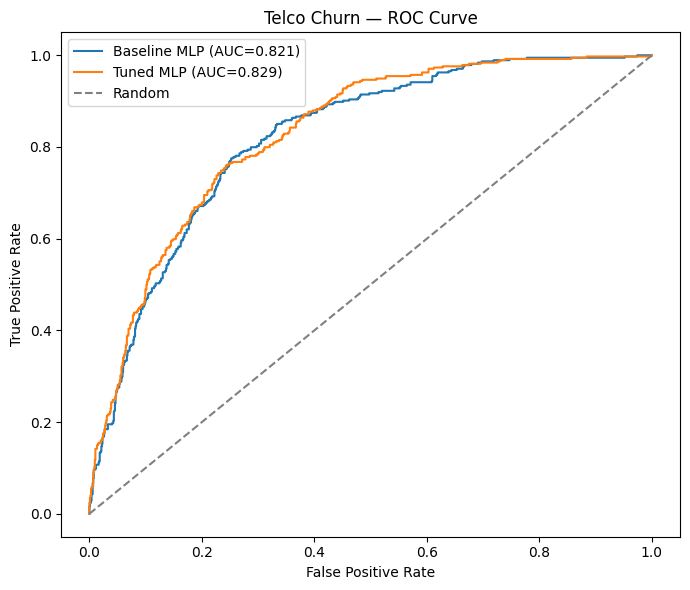

In [23]:
fpr_b, tpr_b, _ = roc_curve(yc_test, proba_base)
fpr_t, tpr_t, _ = roc_curve(yc_test, proba_best)

plt.figure(figsize=(7, 6))
plt.plot(fpr_b, tpr_b, label=f"Baseline MLP (AUC={RESULTS['CS5_baseline_mlp']['roc_auc']:.3f})")
plt.plot(fpr_t, tpr_t, label=f"Tuned MLP (AUC={RESULTS['CS5_tuned_mlp']['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Telco Churn — ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("cs5_roc_curve.png", dpi=130)
plt.show()

---
## Summary

| # | Case Study | Winner | Best score | vs. as-described baseline |
|---|---|---|---|---|
| 1 | Iris | sklearn MLP 1×10 (baseline itself) | 96.7% acc | tied — bigger models did *not* help |
| 2 | Diabetes | Keras MLP (64→32, dropout) | R²=0.493 | +0.10 R² over unregularized baseline |
| 3 | Wine | sklearn MLP 50-25 + early stopping | 97.2% acc | already near-ceiling |
| 4 | Moons/Circles | 50 neurons (single layer) | 99.0% / 98.0% acc | +4.5 pts over 5-neuron on moons |
| 5 | Churn | Grid-searched sklearn MLP | AUC=0.829 | +0.008 AUC / +1.7 acc pts |
